In [4]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from pathlib import Path
from scipy.signal import butter, filtfilt, iirnotch

# Load latest session
files = sorted(Path('../data/raw').glob('session_*.npz'))
latest = files[-1]
d = np.load(latest)
eeg_raw = d['eeg']      # (n_trials, 8, 1000) — kept for reference
labels = d['labels']

print(f"Loaded: {latest.name}")
print(f"Shape: {eeg_raw.shape}  |  Left: {(labels==0).sum()}  Right: {(labels==1).sum()}")

# Filter to 8–30Hz (mu + beta) + 60Hz notch — matches preprocess.py
# Raw epochs are dominated by 60Hz power line noise without this
SRATE = 250
b_notch, a_notch = iirnotch(60.0, Q=30, fs=SRATE)
b_bp, a_bp = butter(4, [8.0, 30.0], btype='band', fs=SRATE)

def _filt(x):
    x = filtfilt(b_notch, a_notch, x)
    x = filtfilt(b_bp, a_bp, x)
    return x

eeg = np.apply_along_axis(_filt, axis=-1, arr=eeg_raw)
print("Filtered: 60Hz notch + 8–30Hz bandpass applied for display")

Loaded: session_2026-05-24_11-40.npz
Shape: (30, 8, 1000)  |  Left: 15  Right: 15
Filtered: 60Hz notch + 8–30Hz bandpass applied for display


In [5]:

# Channels 3 and 4 are 0-indexed as 2 and 3
CH3_IDX = 2
CH4_IDX = 3
SRATE = 250
time_axis = np.linspace(0.5, 4.5, 1000)  # seconds post-cue (epoch window)

left_trials  = eeg[labels == 0]
right_trials = eeg[labels == 1]
n_left  = len(left_trials)
n_right = len(right_trials)

def plot_trial(arm, trial_num):
    trials   = left_trials if arm == 'Left (Ch4 = motor)' else right_trials
    n_trials = n_left      if arm == 'Left (Ch4 = motor)' else n_right
    label    = 'Left arm'  if arm == 'Left (Ch4 = motor)' else 'Right arm'
    idx = trial_num - 1
    if idx >= len(trials):
        return

    fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
    fig.suptitle(f"{label}  —  Trial {trial_num}/{n_trials}", fontsize=14, fontweight='bold')

    for ax, ch_idx, ch_name, color in zip(
        axes,
        [CH3_IDX, CH4_IDX],
        ['Ch 3 (C4 — right motor cortex)', 'Ch 4 (C3 — left motor cortex)'],
        ['#E05A44', '#4682DC']
    ):
        signal = trials[idx, ch_idx, :]
        ax.plot(time_axis, signal, color=color, linewidth=0.9)
        ax.set_ylabel('Amplitude (µV)', fontsize=10)
        ax.set_title(ch_name, fontsize=11)
        ax.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, label='epoch start')
        ax.grid(True, alpha=0.3)
        peak = np.max(np.abs(signal))
        ax.set_ylim(-peak*1.3, peak*1.3)

    axes[-1].set_xlabel('Time post-cue (s)', fontsize=10)
    plt.tight_layout()
    plt.show()

arm_widget = widgets.ToggleButtons(
    options=['Left (Ch4 = motor)', 'Right (Ch3 = motor)'],
    description='Arm:',
    button_style='info'
)
trial_slider = widgets.IntSlider(
    value=1, min=1, max=n_left, step=1,
    description='Trial:',
    continuous_update=False,
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='500px')
)

def update_slider_max(change):
    n = n_left if change['new'] == 'Left (Ch4 = motor)' else n_right
    trial_slider.max = n
    trial_slider.value = min(trial_slider.value, n)

arm_widget.observe(update_slider_max, names='value')

out = widgets.interactive_output(plot_trial, {'arm': arm_widget, 'trial_num': trial_slider})
display(widgets.VBox([arm_widget, trial_slider]), out)


Output()

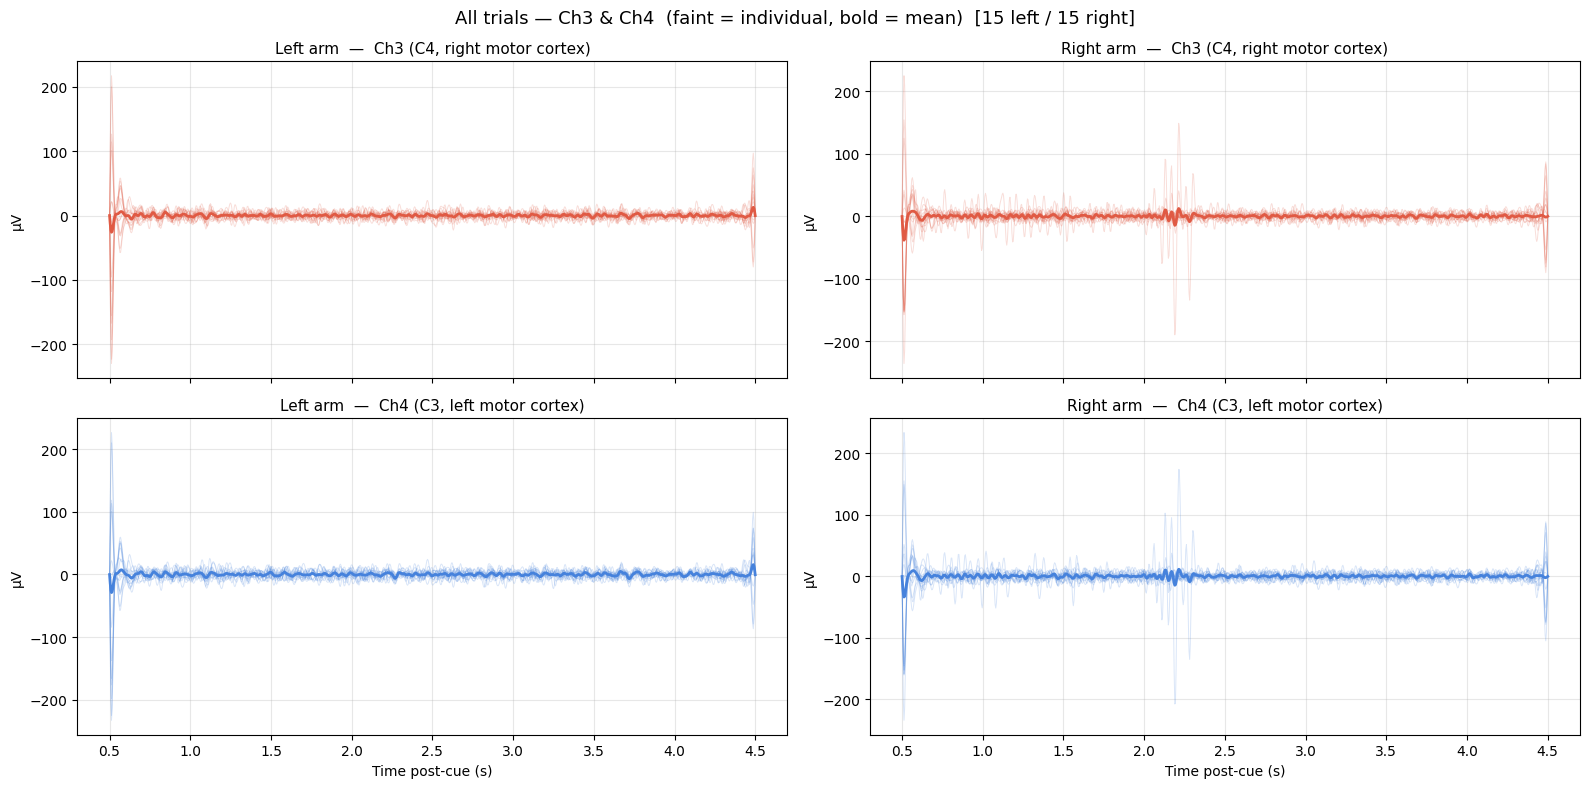

In [6]:

# Overview: all trials for each arm on Ch3 and Ch4
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)
fig.suptitle(
    f'All trials — Ch3 & Ch4  (faint = individual, bold = mean)'
    f'  [{n_left} left / {n_right} right]',
    fontsize=13
)

combos = [
    (left_trials,  CH3_IDX, 'Left arm  —  Ch3 (C4, right motor cortex)', '#E05A44', axes[0,0]),
    (left_trials,  CH4_IDX, 'Left arm  —  Ch4 (C3, left motor cortex)',  '#4682DC', axes[1,0]),
    (right_trials, CH3_IDX, 'Right arm  —  Ch3 (C4, right motor cortex)', '#E05A44', axes[0,1]),
    (right_trials, CH4_IDX, 'Right arm  —  Ch4 (C3, left motor cortex)',  '#4682DC', axes[1,1]),
]

for trials, ch_idx, title, color, ax in combos:
    for t in range(trials.shape[0]):
        ax.plot(time_axis, trials[t, ch_idx, :], color=color, alpha=0.2, linewidth=0.7)
    ax.plot(time_axis, trials[:, ch_idx, :].mean(axis=0), color=color, linewidth=2.0, label='mean')
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('µV')
    ax.grid(True, alpha=0.3)

for ax in axes[-1]:
    ax.set_xlabel('Time post-cue (s)')

plt.tight_layout()
plt.show()
